# Training Director with EfficientNet


## 1. Introduction

In this notebook, we document the process of training our "director" model using [EfficientNet](https://arxiv.org/abs/1905.11946) as a backbone. The director is responsible for the first stage of our streetview geolocation pipeline. This notebook covers the initial setup, our learning process, code improvements, observations, and results.

## 2. EfficientNet & Initial Setup

- We selected **EfficientNet** because of its strong performance and efficiency for image classification tasks.
- We learned the basics of using EfficientNet in PyTorch.
- We implemented a custom dataset class to read images and labels from our CSV metadata.
- To monitor the training process more transparently, we added **progress bars** using `tqdm` for both training and validation loops.


## 3. Hardware Troubles & Solution

- At first, we noticed that **PyTorch was using the CPU** instead of the GPU, leading to slow training.
- After investigating, we found that the issue was due to a too-new Python version (3.13), which wasn't supported by PyTorch+CUDA yet.
- We fixed this by switching to Python 3.10 and reinstalling PyTorch with CUDA support.
- After this change, the code successfully detected and utilized our Nvidia GPU, significantly accelerating training.


## 4. First Training Results

- We trained the initial version of the director model using EfficientNet.
- The model was trained for 5 epochs.
- **Validation accuracy reached approximately 76.1%.**
- The gap between training and validation accuracy indicated some overfitting and room for improvement.


## 5. Improvements & Rationale

To improve generalization and performance, we made several key changes:

### 5.1. Enhanced Data Augmentation

We expanded our `train_transforms` with additional augmentations:
```python
train_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
```
**Why?**
- **RandomHorizontalFlip** and **RandomRotation** help the model become invariant to orientation and mirroring.
- **ColorJitter** introduces variations in brightness, contrast, saturation, and hue, making the model robust to lighting conditions.
- These augmentations increase the diversity of the training data and help reduce overfitting.

### 5.2. Unfreezing All Model Parameters

```python
for param in model.parameters():
    param.requires_grad = True
```
**Why?**
- By default, pretrained models may have some layers "frozen" (not updated during training).
- We allow all layers of EfficientNet to be updated ("fine-tuning"), enabling the model to better adapt to our specific dataset.

### 5.3. Improved Regularization with Adam + Weight Decay

```python
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
```
**Why?**
- The **Adam** optimizer is robust and requires little hyperparameter tuning.
- **Weight decay** acts as L2 regularization, discouraging overly large weights and helping prevent overfitting.



## 6. Director v2 Results

- After applying the above improvements, we trained the model again (director v2).
- **Validation accuracy improved to 76.8%.**
- The model is now slightly better at generalizing to the validation data.


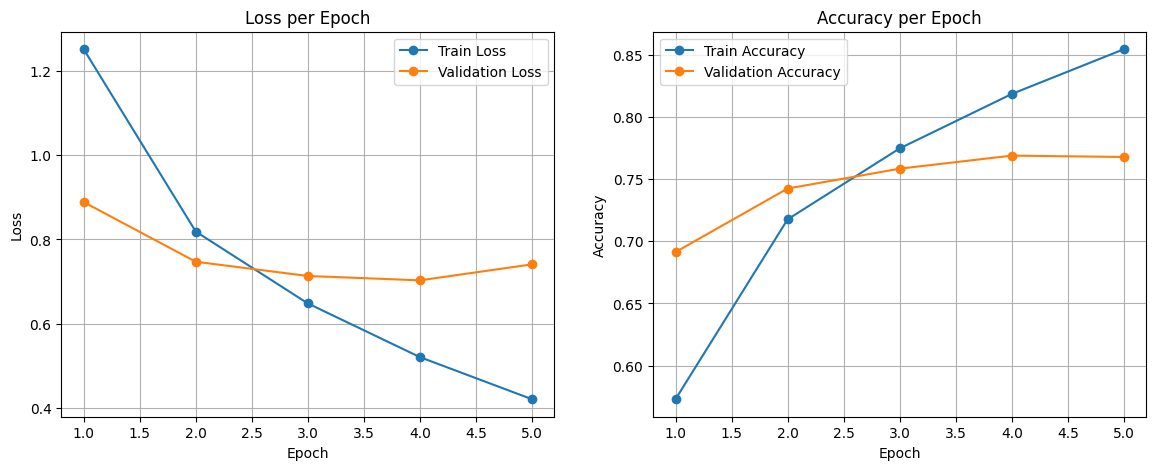

In [7]:
import matplotlib.pyplot as plt

epochs = range(1, 6)

train_losses = [1.2511, 0.8187, 0.6483, 0.5210, 0.4212]
val_losses   = [0.8886, 0.7472, 0.7134, 0.7031, 0.7410]
train_accs   = [0.5729, 0.7176, 0.7747, 0.8185, 0.8545]
val_accs     = [0.6913, 0.7424, 0.7584, 0.7689, 0.7678]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axs[0].plot(epochs, train_losses, label='Train Loss', marker='o')
axs[0].plot(epochs, val_losses, label='Validation Loss', marker='o')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].set_title('Loss per Epoch')
axs[0].legend()
axs[0].grid(True)

# Accuracy
axs[1].plot(epochs, train_accs, label='Train Accuracy', marker='o')
axs[1].plot(epochs, val_accs, label='Validation Accuracy', marker='o')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].set_title('Accuracy per Epoch')
axs[1].legend()
axs[1].grid(True)

plt.show()

## 7. Next Steps

- For now, we are satisfied with the current version of the director.
- The next phase of our project will focus on training the "experts" models, which will handle more fine-grained classification.

*End of notebook section on director training. Ready to move on to the next stage!*# Training Director with EfficientNet